
PERCEPTRON RESULTS
AND: [0 0 0 1]
OR : [0 1 1 1]
XOR: [1 1 0 0] (Fails)

TWO LAYER NN RESULTS
XOR: [0 1 1 0] (Success)


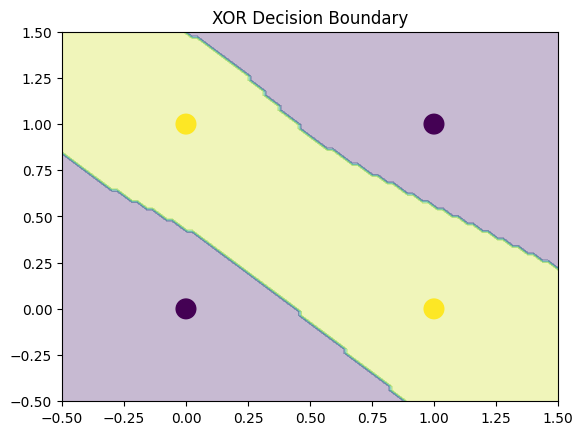

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# PART A: PERCEPTRON
# =========================
class Perceptron:
    def __init__(self):
        self.weights = None
        self.bias = 0

    def train(self, X, y, epochs=20):
        self.weights = np.zeros(X.shape[1])
        for _ in range(epochs):
            for i in range(len(X)):
                pred = 1 if np.dot(X[i], self.weights) + self.bias >= 0 else 0
                error = y[i] - pred
                self.weights += error * X[i]
                self.bias += error

    def predict(self, X):
        return np.array([
            1 if np.dot(x, self.weights) + self.bias >= 0 else 0 for x in X
        ])


# =========================
# PART B: 2-LAYER NN
# =========================
class TwoLayerNN:
    def __init__(self):
        self.W1 = np.random.randn(2, 4) * 0.5
        self.b1 = np.zeros(4)
        self.W2 = np.random.randn(4, 1) * 0.5
        self.b2 = np.zeros(1)

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def train(self, X, y, epochs=5000, lr=0.5):
        y = y.reshape(-1, 1)

        for _ in range(epochs):
            hidden = self.sigmoid(np.dot(X, self.W1) + self.b1)
            output = self.sigmoid(np.dot(hidden, self.W2) + self.b2)

            error = output - y
            hidden_error = error.dot(self.W2.T) * hidden * (1 - hidden)

            # Update
            self.W2 -= lr * hidden.T.dot(error)
            self.b2 -= lr * np.sum(error, axis=0)
            self.W1 -= lr * X.T.dot(hidden_error)
            self.b1 -= lr * np.sum(hidden_error, axis=0)

    def predict(self, X):
        hidden = self.sigmoid(np.dot(X, self.W1) + self.b1)
        output = self.sigmoid(np.dot(hidden, self.W2) + self.b2)
        return (output > 0.5).astype(int).flatten()


# =========================
# MAIN PROGRAM
# =========================
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y_and = np.array([0,0,0,1])
y_or = np.array([0,1,1,1])
y_xor = np.array([0,1,1,0])

print("\nPERCEPTRON RESULTS")
p = Perceptron()

p.train(X, y_and)
print("AND:", p.predict(X))

p.train(X, y_or)
print("OR :", p.predict(X))

p.train(X, y_xor)
print("XOR:", p.predict(X), "(Fails)")

print("\nTWO LAYER NN RESULTS")
nn = TwoLayerNN()
nn.train(X, y_xor)
print("XOR:", nn.predict(X), "(Success)")

# =========================
# VISUALIZATION
# =========================
xx, yy = np.meshgrid(np.linspace(-0.5,1.5,100),
                     np.linspace(-0.5,1.5,100))

grid = np.c_[xx.ravel(), yy.ravel()]
Z = nn.predict(grid).reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X[:,0], X[:,1], c=y_xor, s=200)
plt.title("XOR Decision Boundary")
plt.show()